#[Assignment 10] Feature Engineering; PCA vs Perceptron Transformer!

🚀 *Let’s dive in and make this an awesome learning experience!*

## ✨ Step 0: Importing Base Modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## ✨ Step 1: Load the Dataset

In this assignment, you will work with a dataset called **Fashion-MNIST**. This dataset contains images (60000 for training and 10000 for testing) labeled with 10 different classes:

* 0 - T-shirt/top
* 1 - Trouser
* 2 - Pullover
* 3 - Dress
* 4 - Coat
* 5 - Sandal
* 6 - Shirt
* 7 - Sneaker
* 8 - Bag
* 9 - Ankle boot"

💡 You can read more about the dataset here: https://github.com/zalandoresearch/fashion-mnist

In [2]:
from keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Let's see the size of the arrays

In [3]:
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

Let's look at some of the sample images 🖼️

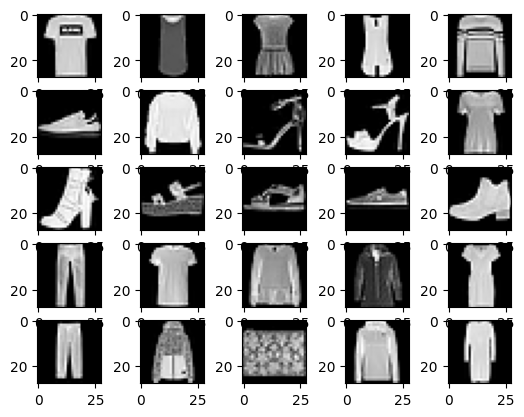

In [4]:
import matplotlib.pyplot as plt
for i in range(1,26):
  plt.subplot(5,5,i)
  plt.imshow(X_train[i],cmap='gray')

##✨ Step 2: Reshape the dataset arrays

1.   **Reshape** the training and testing image arrays so that each image becomes a single row (record), and each pixel becomes a column (feature).
For example, if you have 10,000 images of size 28×28, the reshaped data should have a shape of (10000, 784).
2.   **Invert** the pixel intensities by applying the transformation below — that is, take the absolute difference between 255 and the original value for each pixel::

$$
\text{new value} = |255 - \text{original value}|
$$

💡*This transfomation flips the brightness levels similar to what we did in the lectures — darker pixels become lighter and vice versa.*

In [5]:

X_train_Reshaped = 255 - X_train.reshape(60000, 784)

X_test_Reshaped = X_test_Reshaped  = 255 - X_test.reshape(10000, 784)


If you completed the code above correctly, the following command should show images with white background

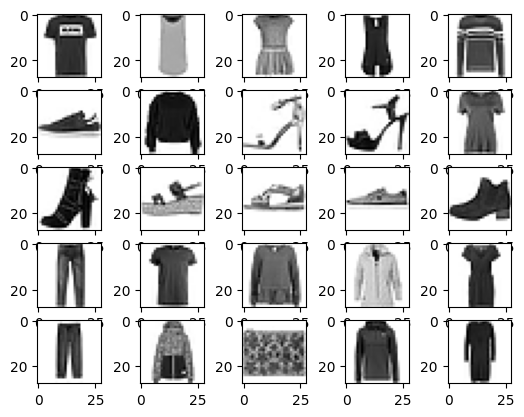

In [6]:
for i in range(1,26):
  plt.subplot(5,5,i)
  plt.imshow(X_train_Reshaped[i].reshape(28,28),cmap='gray')

##✨ Step 3: Building a Pipeline — PCA + Logistic Regression

In this section, we’ll create a pipeline that first applies **PCA (Principal Component Analysis)** to transform and reduce feature dimensions 🧭, and then uses **Logistic Regression**🎯 to classify the data based on these transformed features.

### 🪜 Step 3.1: Applying PCA

▶️ Run the code below to find the first 30 major principle components in the dataset.

⚡ Run the following code exactly as it is — do not change anything!

In [7]:
from sklearn.decomposition import PCA
pca = PCA(n_components=30)
X_train_pca = pca.fit_transform(X_train_Reshaped)
X_test_pca = pca.transform(X_test_Reshaped)

🎯 Find the smallest number of components, `n_components`, that together capture **at least 70% of the total variance** in the training data.

*   You’ll do this by trying different values for `n_components` in the next code block and printing the corresponding `total_variance_n_components` until it reaches (or slightly exceeds) 70%.

💡 Hint: Start with smaller numbers and gradually increase — this helps you see how quickly variance accumulates!

In [13]:
n_components = 9

🎯 Task: Write code to calculate the total variance explained by the selected `n_components`, and store the result in a variable named `total_variance_n_components`.


In [14]:
total_variance_n_components = np.sum(pca.explained_variance_ratio_[:n_components])

In [15]:
print(total_variance_n_components)

0.7067655994598664


### 🪜 Step 3.2 Logistic regression

⚙️ Task: Adjust the parameters of LogisticRegression until no warnings appear during training!

💡  The `max_iter` value must be **less than or equal to 100**, so try experimenting with other parameters to achieve convergence without increasing iterations.


In [16]:
from sklearn.linear_model import LogisticRegression


LGR = LogisticRegression(solver='saga', penalty='l2', max_iter=100, random_state=42)


#Do not change the line below
LGR.fit(X_train_pca[:,0:n_components],y_train)

LogisticRegression(random_state=42, solver='saga')

▶️ Run the following code to view the classification report and confusion matrix for both the training and testing sets.

⚡ Run the following code exactly as it is — do not change anything!

In [17]:
from sklearn.metrics  import classification_report,confusion_matrix,ConfusionMatrixDisplay,f1_score

print("---------Training subset---------\n",classification_report(y_train,LGR.predict(X_train_pca[:,0:n_components])))
print("---------Testing subset----------\n",classification_report(y_test,LGR.predict(X_test_pca[:,0:n_components])))

---------Training subset---------
               precision    recall  f1-score   support

           0       0.71      0.80      0.75      6000
           1       0.94      0.91      0.93      6000
           2       0.55      0.58      0.56      6000
           3       0.75      0.83      0.79      6000
           4       0.61      0.58      0.60      6000
           5       0.80      0.81      0.81      6000
           6       0.49      0.37      0.42      6000
           7       0.79      0.80      0.79      6000
           8       0.92      0.91      0.91      6000
           9       0.87      0.89      0.88      6000

    accuracy                           0.75     60000
   macro avg       0.74      0.75      0.74     60000
weighted avg       0.74      0.75      0.74     60000

---------Testing subset----------
               precision    recall  f1-score   support

           0       0.70      0.78      0.74      1000
           1       0.94      0.90      0.92      1000
        

Text(0.5, 1.0, 'Test Confusion Matrix')

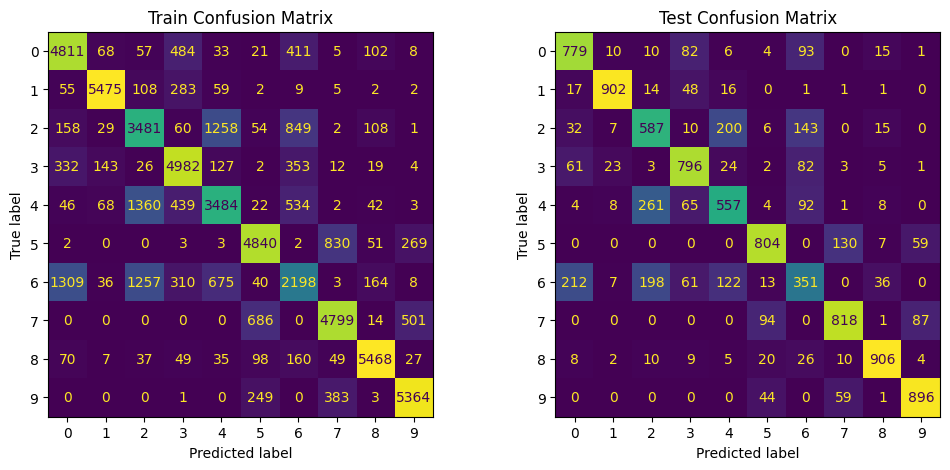

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- 1️⃣ Train Confusion Matrix ---
plt.sca(axes[0])
ConfusionMatrixDisplay(confusion_matrix(y_train,LGR.predict(X_train_pca[:,0:n_components]))).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Train Confusion Matrix")

# --- 2️⃣ Test Confusion Matrix ---
plt.sca(axes[1])
ConfusionMatrixDisplay(confusion_matrix(y_test,LGR.predict(X_test_pca[:,0:n_components]))).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Test Confusion Matrix")

Based on the above values, which class has the largest number of misclassified records?

In [19]:
Worstclass_LGR = 6

##✨ Step 4: Multi-Layer Perceptron (MLP)

**Read Carefully:**

In the previous section, we applied a linear classifier — LogisticRegression — on a reduced feature set obtained using PCA and achieved an accuracy of around 70%.

**Pipeline Recap:**

*   Original Features (784 features) ➡️ PCA ➡️ Transformed Features
(n_components) ➡️ Logistic Regression

Now, let’s take it a step further! 🎯

In this section, we’ll build a **Multi-Layer Perceptron (MLP)** network that uses a hidden layer with **the same number of neurons** as `n_components`.
This hidden layer will learn **a non-linear transformation** of the data — similar to PCA, but more powerful — and we’ll use the final layer for classification.

**New Pipeline:**

*   Original Features (784 features) ➡️ Hidden Layer Perceptrons ➡️ Transformed Features (n_components) ➡️ Output Layer Perceptrons

💡 *In short: instead of letting PCA **linearly** transform the data, we’re letting the MLP learn its own transformation — and then classify based on it!*

### 🪜 Step 4.1 Normalizing the features

Never forget that you need to normalize the features before training **Neural Networks**. Complete the following code and normalize the features using `StandardScaler`

In [20]:
from sklearn.preprocessing import StandardScaler
#Complete the code below

scaler = StandardScaler()


X_train_Reshaped_normalized= scaler.fit_transform(X_train_Reshaped)
X_test_Reshaped_Normalized = scaler.transform(X_test_Reshaped)



### 🪜 Step 4.2 Training the MLP

⚡ Run the following code exactly as it is — do not change anything!

⏳ This code may take up to 3 minutes to run, so please be patient.

In [21]:
from sklearn.neural_network import MLPClassifier
MLP=MLPClassifier(hidden_layer_sizes=(n_components,),max_iter=300)
MLP.fit(X_train_Reshaped_normalized,y_train)

MLPClassifier(hidden_layer_sizes=(9,), max_iter=300)

▶️ Run the following code to view the classification report and confusion matrix for both the training and testing sets.

This demonstrates the performance of a two-layer perceptron —
the first layer transforms the 784 original features into `n_components` features, and the second layer performs the classification.

In [22]:
from sklearn.metrics  import classification_report,confusion_matrix,ConfusionMatrixDisplay

print("---------Training subset---------\n",classification_report(y_train,MLP.predict(X_train_Reshaped_normalized)))
print("---------Testing subset----------\n",classification_report(y_test,MLP.predict(X_test_Reshaped_Normalized)))

---------Training subset---------
               precision    recall  f1-score   support

           0       0.85      0.83      0.84      6000
           1       0.98      0.99      0.98      6000
           2       0.81      0.82      0.82      6000
           3       0.89      0.91      0.90      6000
           4       0.82      0.82      0.82      6000
           5       1.00      0.96      0.98      6000
           6       0.74      0.73      0.73      6000
           7       0.94      0.98      0.96      6000
           8       0.99      0.99      0.99      6000
           9       0.98      0.97      0.97      6000

    accuracy                           0.90     60000
   macro avg       0.90      0.90      0.90     60000
weighted avg       0.90      0.90      0.90     60000

---------Testing subset----------
               precision    recall  f1-score   support

           0       0.80      0.77      0.79      1000
           1       0.95      0.95      0.95      1000
        

Text(0.5, 1.0, 'Test Confusion Matrix')

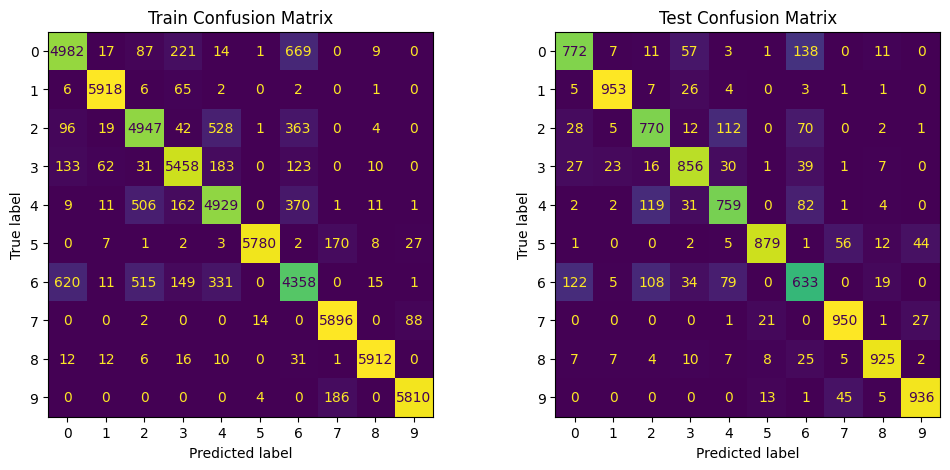

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- 1️⃣ Train Confusion Matrix ---
plt.sca(axes[0])
ConfusionMatrixDisplay(confusion_matrix(y_train,MLP.predict(X_train_Reshaped_normalized))).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Train Confusion Matrix")

# --- 2️⃣ Test Confusion Matrix ---
plt.sca(axes[1])
ConfusionMatrixDisplay(confusion_matrix(y_test,MLP.predict(X_test_Reshaped_Normalized))).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Test Confusion Matrix")

🏁 As expected, the two-layer perceptron outperforms the PCA + Logistic Regression approach. 🎯

*   This happens because **the hidden layer perceptron** acts as a **non-linear feature transformer.**
*   During training, the model **learns and optimizes** the transformation weights to create the most effective feature representation — which ultimately leads to **better classification performance.** 🚀



###🪜 Step 4.3 — Extracting Features from the First Layer

Accessing **MLP.coefs_[0]** and **MLP.intercepts_[0]** allows us to retrieve the **weights and biases** of the hidden layer.
*   The **input dimension** of this layer is **784**, corresponding to the original features (pixels).
*   The **output dimension is 9**, representing the **transformed features** learned by the hidden layer.

Now, complete the following code block to compute **the output of the hidden layer** (i.e., the transformed features).

💡 As a quick reminder:
*   np.matmul(x, y) → performs matrix multiplication of arrays x and y.
*   np.maximum(x, 0) → applies the ReLU activation function on all elements of array x.

In [25]:
X_train_Reshaped_normalized_Transformed = np.maximum(0, np.matmul(X_train_Reshaped_normalized, MLP.coefs_[0]) + MLP.intercepts_[0])

X_test_Reshaped_normalized_Transformed = np.maximum(0, np.matmul(X_test_Reshaped_Normalized, MLP.coefs_[0]) + MLP.intercepts_[0])

If your code is correct, running the following two lines should both return True ✅

In [26]:
isinstance(X_train_Reshaped_normalized_Transformed, np.ndarray) and isinstance(X_test_Reshaped_normalized_Transformed, np.ndarray)

True

In [27]:
X_train_Reshaped_normalized_Transformed.shape==(60000,n_components) and X_test_Reshaped_normalized_Transformed.shape==(10000,n_components)

True

###🪜 Step 4.4 — Logistic Regression

In this step, we’ll train a **Logistic Regression** model using the **transformed features** obtained from the hidden layer of the two-layer perceptron. The goal is to see whether this approach yields better results than **the PCA + Logistic Regression (PCA+LGR)** method.

Set the model parameters exactly **as you did in Step 3.2**.

*💡 Remember: the maximum number of iterations (max_iter) must be less than or equal to 100.*

In [28]:
from sklearn.linear_model import LogisticRegression
LGR2 = LogisticRegression(solver='saga', penalty='l2', max_iter=100, random_state=42)

#Do not change the line below
LGR2.fit(X_train_Reshaped_normalized_Transformed,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(random_state=42, solver='saga')

▶️ Run the following code to view the classification report and confusion matrix for both the training and testing sets.

In [29]:
from sklearn.metrics  import classification_report,confusion_matrix,ConfusionMatrixDisplay

print("---------Training subset---------\n",classification_report(y_train,LGR2.predict(X_train_Reshaped_normalized_Transformed)))
print("---------Testing subset----------\n",classification_report(y_test,LGR2.predict(X_test_Reshaped_normalized_Transformed)))

---------Training subset---------
               precision    recall  f1-score   support

           0       0.83      0.85      0.84      6000
           1       0.99      0.98      0.98      6000
           2       0.82      0.81      0.82      6000
           3       0.88      0.92      0.90      6000
           4       0.81      0.83      0.82      6000
           5       0.98      0.98      0.98      6000
           6       0.75      0.70      0.73      6000
           7       0.96      0.97      0.97      6000
           8       0.99      0.98      0.98      6000
           9       0.97      0.97      0.97      6000

    accuracy                           0.90     60000
   macro avg       0.90      0.90      0.90     60000
weighted avg       0.90      0.90      0.90     60000

---------Testing subset----------
               precision    recall  f1-score   support

           0       0.78      0.79      0.79      1000
           1       0.97      0.95      0.96      1000
        

Text(0.5, 1.0, 'Test Confusion Matrix')

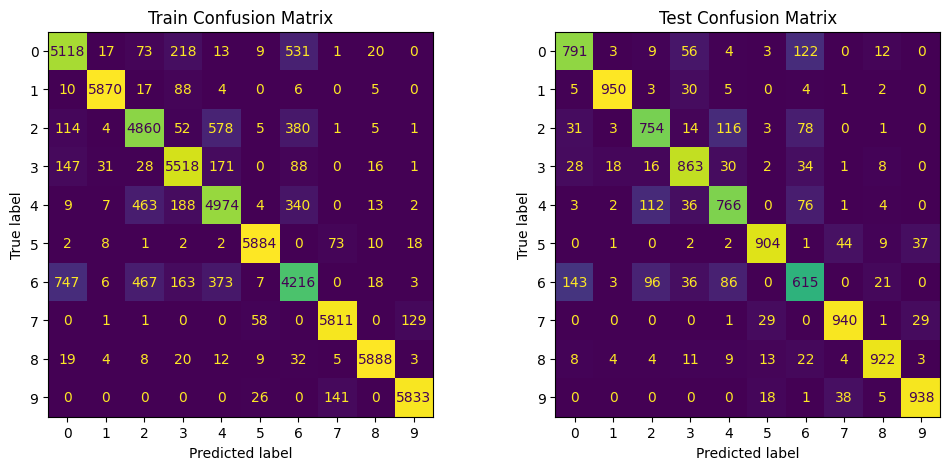

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- 1️⃣ Train Confusion Matrix ---
plt.sca(axes[0])
ConfusionMatrixDisplay(confusion_matrix(y_train,LGR2.predict(X_train_Reshaped_normalized_Transformed))).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Train Confusion Matrix")

# --- 2️⃣ Test Confusion Matrix ---
plt.sca(axes[1])
ConfusionMatrixDisplay(confusion_matrix(y_test,LGR2.predict(X_test_Reshaped_normalized_Transformed))).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Test Confusion Matrix")

## 🔚 Final Remarks — Wrapping It All Up! 🎓

**Important! 🚨**

In this notebook, we explored **three powerful pipelines** for transforming and classifying features:
1.   **🧩 Pipeline 1:** Feature transformation using PCA, followed by a Linear Classifier (Logistic Regression).
2.	**⚙️ Pipeline 2:** A two-layer Perceptron, where the first layer performs feature transformation and the second layer classifies.
3.	**🔁 Pipeline 3:** Feature transformation using a Hidden Layer Perceptron, followed by a Linear Classifier (Logistic Regression).

✨ The key takeaway:
**The two-layer perceptron** — where the first layer transforms features and the second layer classifies — should achieve **higher accuracy** on the test dataset than the PCA + Logistic Regression pipeline.

This demonstrates that the first layer of the neural network performs a more powerful, non-linear feature transformation than PCA.

Finally, by applying **Logistic Regression** on the **transformed features** from the hidden layer of the MLP and achieving a **similar performance**, we confirmed that the improvement truly comes from the **feature transformation** learned by the neural network itself. 💡
